In [2]:
import torch
from torch.autograd import grad
from scipy.io import savemat, loadmat


import pandas as pd
import seaborn as sns
import math
import scipy.io as sio
import matplotlib.pyplot as plt
from pinnutils import *
from chebyshev_utils import *
from GEOMLOSS import samples_loss
from tqdm import tqdm_notebook as tqdm
import os
from genesets import genesets
from genesets_exvivo import genesets_exvivo

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:32768"

import scvelo as scv
import scanpy as sc
import anndata as ad

from TrajectoryNet.parse import parser
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

import matplotlib as mpl
mpl.rcParams.update({# Use mathtext, not LaTeX
                            'text.usetex': False,
                            # Use the Computer modern font
                            'font.family': 'serif',
                            'font.serif': 'cmr10',
                            'mathtext.fontset': 'cm',
                            # Use ASCII minus
                            'axes.unicode_minus': False,
                            })

cuda


In [33]:
# def load_data(path,nsamples,genes,time_str,cell_type_str):
#     Ndim = len(genes);
#     args = parser.parse_args(args=[])
#     args.dataset = path
#     adata = sc.read_h5ad(args.dataset)

#     unique_times = adata.obs[str(time_str)].unique()
#     unique_times = unique_times[unique_times != 5.0]   # remove day 5
    
#     nsnaps = len(unique_times); 
#     samples = np.zeros((len(unique_times),nsamples,Ndim+1))

#     print(adata.obs)
    
#     cell_type_categories = list(adata.obs[str(cell_type_str)].cat.categories)
#     cell_type_to_int = {ct: i for i, ct in enumerate(cell_type_categories)}
#     ind_array = np.zeros((nsnaps, nsamples), dtype=int)

#     print(cell_type_categories, cell_type_to_int)

#     for k in range(0,nsnaps):
        
#         time_point = unique_times[k] # Replace with actual time (e.g., "10h" or 10)
#         cells_at_time = adata[adata.obs[str(time_str)] == time_point]
#         cell_names = cells_at_time.obs_names.tolist()
#         selected = np.arange(0,nsamples)

#         cell_types_k = cells_at_time.obs[str(cell_type_str)].iloc[selected].values
#         ind_array[k, :] = [cell_type_to_int[ct] for ct in cell_types_k]
    
#         expression_t0 = cells_at_time[:, genes].X
#         expression_t0_numpy = expression_t0.toarray() if hasattr(expression_t0, "toarray") else np.array(expression_t0)
#         print(" shape ", k, " : ", expression_t0_numpy.shape)
        
#         samples[k,:,0:Ndim] = expression_t0_numpy[selected,:]
#         samples[k,:,Ndim]   = k

#     return samples, unique_times, ind_array, adata.obs[str(cell_type_str)]


def load_data(path,nsamples,genes,time_str,cell_type_str):
    Ndim = len(genes);
    args = parser.parse_args(args=[])
    args.dataset = path
    adata = sc.read_h5ad(args.dataset)

    unique_times = adata.obs[str(time_str)].unique()
    # unique_times = unique_times[unique_times != 5.0]
    nsnaps = len(unique_times); 
    samples = np.zeros((len(unique_times),nsamples,Ndim+1))

    cell_type_categories = list(adata.obs[str(cell_type_str)].cat.categories)
    cell_type_to_int = {ct: i for i, ct in enumerate(cell_type_categories)}
    ind_array = np.zeros((nsnaps, nsamples), dtype=int)

    print(cell_type_categories, cell_type_to_int)
    for k in range(0,len(unique_times)):
        time_point = unique_times[k] # Replace with actual time (e.g., "10h" or 10)
        cells_at_time = adata[adata.obs[str(time_str)] == time_point]
        cell_names = cells_at_time.obs_names.tolist()
        selected = np.arange(0,nsamples)

        expression_t0 = cells_at_time[:, genes].X
        expression_t0 = cells_at_time[:, genes].X
        
        expression_t0_numpy = expression_t0.toarray() if hasattr(expression_t0, "toarray") else np.array(expression_t0)
        print(" shape ", k, " : ", expression_t0_numpy.shape)

        randind = np.arange(0, len(cell_names))
        half = int(nsamples/1)
        for ll in range(0,1):
            np.random.shuffle(randind); 
            selected =  randind[0:half] # np.arange(0,nsamples)
            cell_types_k = cells_at_time.obs[str(cell_type_str)].iloc[selected].values
            ind_array[k, ll*half:(ll+1)*half] = [cell_type_to_int[ct] for ct in cell_types_k]
            samples[k,ll*half:(ll+1)*half,0:Ndim] = expression_t0_numpy[selected,:]
            samples[k,ll*half:(ll+1)*half,Ndim]   = unique_times[k]
            print(" time ", unique_times[k])

    return samples, unique_times, ind_array, adata.obs[str(cell_type_str)]

geneset_num = 1
genes =  [ "etv2", "nr2f2", "mecom", "hhex", "hand2", "snai2", "pitx1", "fli1", "foxo1", "ebf1", "trps1", "lef1", "zeb2",
           "pbx1", "pbx3", "meis1", "erg", "gata2", "sox7", "sox18", "ets1", "nr3c1", "foxq1"
]

print(" genes used ", genes)

nsamples = 4_100; 
path = '/mnt/home/vchardes/ceph/datasets/vascular_data/anndata/invitro_timecourse.h5ad'
samples, tp, ind_array, cell_type = load_data(path,nsamples,genes,"day","annot_celltype")
Ndim = len(genes);
Dist = samples[:,:,:]
print(" samples shape ", samples.shape, ind_array.shape)
print(cell_type)

 genes used  ['etv2', 'nr2f2', 'mecom', 'hhex', 'hand2', 'snai2', 'pitx1', 'fli1', 'foxo1', 'ebf1', 'trps1', 'lef1', 'zeb2', 'pbx1', 'pbx3', 'meis1', 'erg', 'gata2', 'sox7', 'sox18', 'ets1', 'nr3c1', 'foxq1']
['Endo', 'Epi-1', 'Epi-2', 'Mesoderm', 'Mural', 'NC', 'PSC'] {'Endo': 0, 'Epi-1': 1, 'Epi-2': 2, 'Mesoderm': 3, 'Mural': 4, 'NC': 5, 'PSC': 6}
 shape  0  :  (8642, 23)
 time  0.0
 shape  1  :  (5409, 23)
 time  3.0
 shape  2  :  (6793, 23)
 time  4.0
 shape  3  :  (4130, 23)
 time  5.0
 shape  4  :  (5166, 23)
 time  6.0
 shape  5  :  (6264, 23)
 time  7.0
 shape  6  :  (9460, 23)
 time  14.0
 shape  7  :  (6816, 23)
 time  21.0
 samples shape  (8, 4100, 24) (8, 4100)
SC_AAACCCAAGCTTAGTC              PSC
SC_AAACCCAAGTAATCCC              PSC
SC_AAACCCACACTGGACC              PSC
SC_AAACCCAGTCGTATTG              PSC
SC_AAACCCAGTCGTGGAA              PSC
                               ...  
NC8day14_TTTGTTGAGCCTCTCT-1    Mural
NC8day14_TTTGTTGAGTTCCGGC-1     Endo
NC8day14_TTTGTTGGTGGAT

In [34]:
Dist[:,0,-1]

array([ 0.,  3.,  4.,  5.,  6.,  7., 14., 21.])

In [35]:
tp, Dist.shape

(array([ 0.,  3.,  4.,  5.,  6.,  7., 14., 21.]), (8, 4100, 24))

In [36]:
def gradient_field(phi_,inp_):
    
    gradient = grad(outputs=phi_,inputs=inp_,
                      grad_outputs=torch.ones_like(phi_), 
                      create_graph=True)[0]

    return gradient

def simulate_inferrred_interpolation(drift_net, samples, tp, lx, nm, pert_flag=False, pert_ind=0, intrpl_flag=False):
    loss_fn = samples_loss.SamplesLoss("energy")
    drift_net.eval()

    K, Ndata, Ndim = samples.shape
    K = samples.shape[0]; Ndata = samples.shape[1];
    Ndim  = samples.shape[2]-1;

    init = torch.zeros((Ndata, Ndim + 1), device=device)
    init[:, :Ndim] = torch.tensor(samples[0, :, :Ndim], dtype=torch.float32, device=device)
    init[:, Ndim] = tp[0]  # start sim_time from tp[0]

    Xold = init.clone().detach()
    inf_dt = 0.01
    max_time = tp[-1]
    sim_time = tp[0]
    tp_idx = 0
    total_err = 0.0
    kappa = 0.1

    store_path = [];
    while sim_time <= max_time and tp_idx < K:
        with torch.no_grad():
            #if(nm=="Langevin"):
            if(nm=="Langevin" or nm=="Langevin_new"):
                drift = drift_net(Xold[:, :Ndim])
                noise = (1 ** 0.5)*torch.sqrt((drift + lx * Xold[:, :Ndim])) * (inf_dt ** 0.5) * torch.randn((Ndata, Ndim), device=device)
                #noise = torch.sqrt(torch.relu(Xold[:, :Ndim])) * (inf_dt ** 0.5) * torch.randn((Ndata, Ndim), device=device)
                Xnew = Xold.clone()
                Xnew[:, :Ndim] = Xold[:, :Ndim] + (drift - lx * Xold[:, :Ndim]) * inf_dt + noise
                if(pert_flag): Xnew[:,pert_ind] = 0;
                # Xnew[:,3] = 5;
            elif(nm=="Mult"):
                drift = drift_net(Xold[:, :Ndim])
                noise = torch.sqrt(torch.relu(Xold[:, :Ndim])) * (inf_dt ** 0.5) * torch.randn((Ndata, Ndim), device=device)
                Xnew = Xold.clone()
                Xnew[:, :Ndim] = Xold[:, :Ndim] + (drift - lx * Xold[:, :Ndim]) * inf_dt + noise
                if(pert_flag): Xnew[:,pert_ind] = 0;
            elif(nm=="Additive"):
                drift = drift_net(Xold[:, :Ndim])
                noise =  (inf_dt ** 0.5) * torch.randn((Ndata, Ndim), device=device)
                Xnew = Xold.clone()      
                Xnew[:, :Ndim] = Xold[:, :Ndim] + (drift - lx * Xold[:, :Ndim]) * inf_dt + noise
                if(pert_flag): Xnew[:,pert_ind] = 0;
            elif(nm=="ODE"):
                drift = drift_net(Xold[:, :Ndim])
                Xnew = Xold.clone()      
                Xnew[:, :Ndim] = Xold[:, :Ndim] + (drift - lx * Xold[:, :Ndim]) * inf_dt 
                if(pert_flag): Xnew[:,pert_ind] = 0;
            elif(nm=="pres"):
                noise =  (2.0 ** 0.5)*(inf_dt ** 0.5) * torch.randn((Ndata, Ndim), device=device)  
                with torch.enable_grad():
                    inp_ = Xold[:, 0:Ndim].clone()
                    inp_.requires_grad_()
                    phi = drift_net(inp_)
                    grad_drift  = gradient_field(phi, inp_)   
                    Xnew = Xold.clone()    
                    Xnew[:, :Ndim] = Xold[:, :Ndim] + (- grad_drift - lx*Xold[:,0:Ndim]) * inf_dt + 0.1*noise 
                if(pert_flag): Xnew[:,pert_ind] = 0;
            else:
                drift = drift_net(Xold[:, :])
                Xnew = Xold.clone()      
                Xnew[:, :Ndim] = Xold[:, :Ndim] + 1*(drift - lx * Xold[:, :Ndim]) * inf_dt 
                if(pert_flag): Xnew[:,pert_ind] = 0;

            Xnew[:, Ndim] += inf_dt
            # Handle invalid values
            neg_idx = Xnew[:, :Ndim] < 0
            Xnew[:, :Ndim][neg_idx] = Xold[:, :Ndim][neg_idx]
            nan_idx = torch.isnan(Xnew[:, :Ndim])
            Xnew[:, :Ndim][nan_idx] = Xold[:, :Ndim][nan_idx]

            Xold = Xnew + 0;
            sim_time = Xold[0, Ndim].item()

            if(intrpl_flag):
                # Compute loss at matching tp
                while tp_idx < K and sim_time >= tp[tp_idx] - 1e-6:
                    store_path.append(Xold[:,:Ndim].cpu().data.numpy())
                    generated = Xold[:Ndata, :Ndim]
                    target = torch.tensor(samples[tp_idx, :Ndata, :Ndim], dtype=torch.float32, device=device)
                    e_loss = loss_fn(target, generated)
                    total_err += e_loss
                    tp_idx += 1

    if(intrpl_flag):
        return np.stack(store_path), total_err / K
    else:
        return Xold[:, :Ndim].data.cpu().numpy()

In [37]:
lx, Np, Nf = 0.7, 150, 150
seed_list = np.array([0, 1, 2, 3, 4])
intpl_err = np.zeros((6, len(seed_list)))

model_list = ['Langevin', 'Mult', 'Additive', 'ODE', 'pres', 'TrajNet']

base_path = "/mnt/ceph/users/smaddu/stochastic_inference"
gen_outputs = {model: {} for model in model_list}
for s_idx, seed in enumerate(seed_list):
    common_args = f"N5000_Ndim{Ndim}_Np{Np}_Nf{Nf}_fac2_seed{seed}"
    model_paths = {
        "Langevin":  f"{base_path}/fm_newset_fullspectral_vascular_{common_args}_dmLangevin_lx{lx}_set{geneset_num}.path",
        "Mult":      f"{base_path}/fm_newset_fullspectral_vascular_{common_args}_dmMult_lx{lx}_set{geneset_num}.path",
        "Additive":  f"{base_path}/fm_newset_fullspectral_vascular_{common_args}_dmAdditive_lx{lx}_set{geneset_num}.path",
        "ODE":       f"{base_path}/fm_newset_fullspectral_vascular_{common_args}_dmODE_lx{lx}_set{geneset_num}.path",
        "pres": f"{base_path}/fm_newset_fullspectral_prescient_vascular_{common_args}_dmLangevin_lx{lx}_set{geneset_num}.path",
        "TrajNet":   f"{base_path}/fm_newset_fullspectral_TrajNet_vascular_{common_args}_dmLangevin_lx{lx}_set{geneset_num}.path"
    }
    
    for m_idx, (model_name, model_path) in enumerate(model_paths.items()):
        print(model_name, model_path, seed)
        drift_net = torch.load(model_path,map_location='cuda',weights_only=False).eval()
        gen_output, error = simulate_inferrred_interpolation(drift_net, Dist[:, :5000, :], tp, lx, nm=model_name, intrpl_flag=True)
        
        # # Store output and error
        gen_outputs[model_name][seed] = gen_output
        intpl_err[m_idx, s_idx] = error
        
        print(f"Total error ({model_name}, seed {seed}): {error:.4f}")

Langevin /mnt/ceph/users/smaddu/stochastic_inference/fm_newset_fullspectral_vascular_N5000_Ndim23_Np150_Nf150_fac2_seed0_dmLangevin_lx0.7_set1.path 0
Total error (Langevin, seed 0): 0.8685
Mult /mnt/ceph/users/smaddu/stochastic_inference/fm_newset_fullspectral_vascular_N5000_Ndim23_Np150_Nf150_fac2_seed0_dmMult_lx0.7_set1.path 0
Total error (Mult, seed 0): 1.0766
Additive /mnt/ceph/users/smaddu/stochastic_inference/fm_newset_fullspectral_vascular_N5000_Ndim23_Np150_Nf150_fac2_seed0_dmAdditive_lx0.7_set1.path 0
Total error (Additive, seed 0): 1.5153
ODE /mnt/ceph/users/smaddu/stochastic_inference/fm_newset_fullspectral_vascular_N5000_Ndim23_Np150_Nf150_fac2_seed0_dmODE_lx0.7_set1.path 0
Total error (ODE, seed 0): 1.7508
pres /mnt/ceph/users/smaddu/stochastic_inference/fm_newset_fullspectral_prescient_vascular_N5000_Ndim23_Np150_Nf150_fac2_seed0_dmLangevin_lx0.7_set1.path 0
Total error (pres, seed 0): 2.4040
TrajNet /mnt/ceph/users/smaddu/stochastic_inference/fm_newset_fullspectral_TrajN

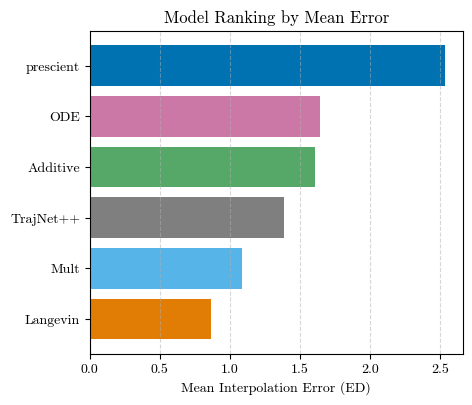

In [38]:
plt.subplot(1,1,1)
records = []

data = {
    'Langevin': intpl_err[0,:],
    'Mult': intpl_err[1,:],
    'Additive': intpl_err[2,:],
    'ODE': intpl_err[3,:],
    'prescient': intpl_err[4,:],
    'TrajNet++': intpl_err[5,:]
}

for model, vals in data.items():
    for v in vals:
        records.append({'Model': model, 'Error': v})

colors = ['#E17C05', #'#E69F00',  # orange
          '#56B4E9',  # sky blue
          '#55A868', #'#009E73',  # bluish green
          '#CC78A7', #'#F0E442',  # yellow
          '#0072B2',  # blue
          '#7F7F7F'] #'#D55E00']  # vermillion

# Compute and sort by mean error
mean_errors = {model: np.mean(vals) for model, vals in data.items()}
sorted_items = sorted(mean_errors.items(), key=lambda x: x[1])  # ascending

models, means = zip(*sorted_items)
# Assign colors in sorted order
sorted_colors = [colors[i] for i in np.argsort(list(mean_errors.values()))]

bars = plt.barh(models, means, color=sorted_colors)
plt.xlabel('Mean Interpolation Error (ED)')
plt.title('Model Ranking by Mean Error')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.gcf().set_size_inches(4.5, 4)
# plt.savefig('results/exvivo_err.svg')